In [39]:
%pip install scikit-learn

  Using cached scikit_learn-1.6.1-cp311-cp311-win_amd64.whl.metadata (15 kB)
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.6.1-cp311-cp311-win_amd64.whl (11.1 MB)
Using cached joblib-1.4.2-py3-none-any.whl (301 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd

In [36]:
import pandas as pd
import os
df = pd.read_csv("KR_youtube_trending_data.csv", encoding='utf-8')
df.columns

Index(['video_id', 'title', 'publishedAt', 'channelId', 'channelTitle',
       'categoryId', 'trending_date', 'tags', 'view_count', 'likes',
       'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled',
       'ratings_disabled', 'description'],
      dtype='object')

In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import joblib  # 모델 저장용

# 1. 데이터 불러오기
df = pd.read_csv("KR_youtube_trending_data.csv", encoding='utf-8')

# 2. 필요한 컬럼만 추출 + 결측치 제거
df = df[["video_id", "categoryId", "likes", "comment_count", "dislikes"]]
df = df.dropna()
df = df[df["dislikes"] >= 0]

# 3. categoryId → 문자열로 변환 후 One-Hot Encoding
df["categoryId"] = df["categoryId"].astype(str)
X = df[["categoryId", "likes", "comment_count"]]
X = pd.get_dummies(X, columns=["categoryId"])
y = df["dislikes"]

# 4. 훈련/검증 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. 모델 정의 및 학습
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. 성능 평가 (RMSE 계산)
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"✅ 모델 학습 완료! RMSE: {rmse:.2f}")

# 7. 모델 및 feature column 저장
joblib.dump(model, "dislike_predictor_model.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")
print("✅ 모델 및 feature column 저장 완료!")


✅ 모델 학습 완료! RMSE: 4521.85
✅ 모델 및 feature column 저장 완료!


✅ 모델 학습 완료! RMSE: 4521.85
✅ 모델 및 피처 저장 완료


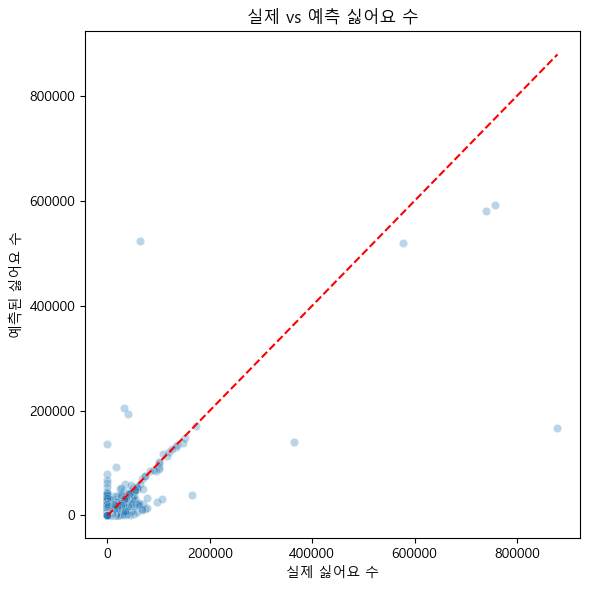

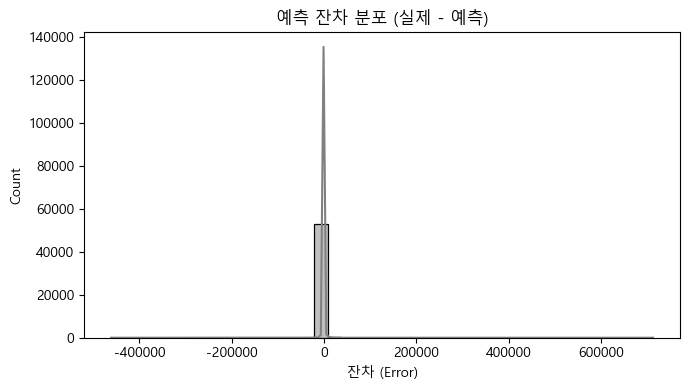

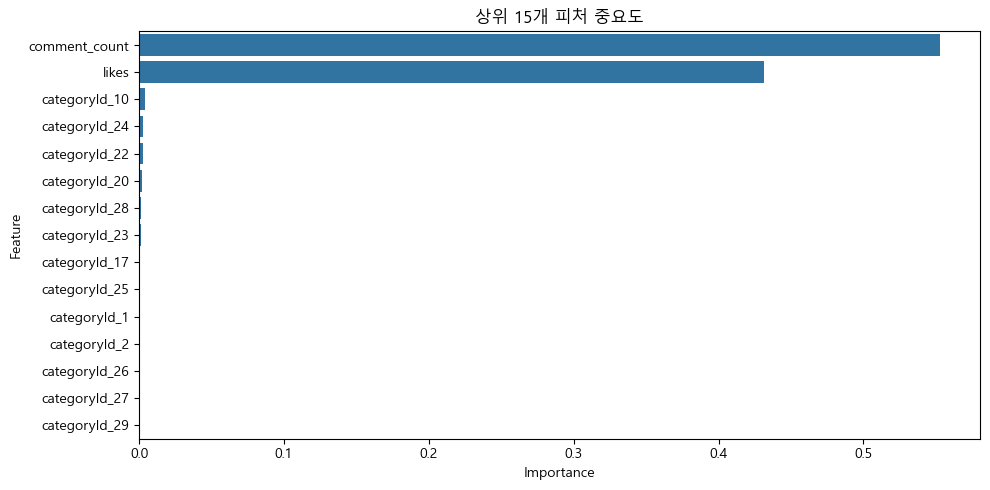

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.font_manager as fm
import platform

# ===============================
# ✅ 한글 폰트 설정
# ===============================
def set_korean_font():
    if platform.system() == 'Windows':
        plt.rc('font', family='Malgun Gothic')  # 윈도우용
    elif platform.system() == 'Darwin':
        plt.rc('font', family='AppleGothic')  # 맥용
    else:
        plt.rc('font', family='NanumGothic')  # 리눅스용 or colab
    plt.rc('axes', unicode_minus=False)

set_korean_font()

# ===============================
# ✅ 1. 데이터 로딩 및 전처리
# ===============================
df = pd.read_csv("KR_youtube_trending_data.csv", encoding='utf-8')

df = df[["video_id", "categoryId", "likes", "comment_count", "dislikes"]]
df = df.dropna()
df = df[df["dislikes"] >= 0]
df["categoryId"] = df["categoryId"].astype(str)

X = df[["categoryId", "likes", "comment_count"]]
X = pd.get_dummies(X, columns=["categoryId"])
y = df["dislikes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# ✅ 2. 모델 학습
# ===============================
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ===============================
# ✅ 3. 성능 평가 및 저장
# ===============================
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"✅ 모델 학습 완료! RMSE: {rmse:.2f}")

joblib.dump(model, "dislike_predictor_model.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")
print("✅ 모델 및 피처 저장 완료")

# ===============================
# ✅ 4. 시각화
# ===============================

# 1️⃣ 실제값 vs 예측값 산점도
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("실제 싫어요 수")
plt.ylabel("예측된 싫어요 수")
plt.title("실제 vs 예측 싫어요 수")
plt.tight_layout()
plt.show()

# 2️⃣ 잔차 히스토그램
residuals = y_test - y_pred
plt.figure(figsize=(7, 4))
sns.histplot(residuals, bins=40, kde=True, color='gray')
plt.title("예측 잔차 분포 (실제 - 예측)")
plt.xlabel("잔차 (Error)")
plt.tight_layout()
plt.show()

# 3️⃣ 피처 중요도
importances = model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df.head(15), x="Importance", y="Feature")
plt.title("상위 15개 피처 중요도")
plt.tight_layout()
plt.show()
